## 🌍 Análise da Evolução da Obesidade Mundial (1975–2016)

A obesidade é um dos maiores problemas de saúde pública no mundo. 
Nas últimas décadas, diversos países apresentaram crescimento significativo 
nas taxas de obesidade, impactando sistemas de saúde e qualidade de vida.

Neste projeto realizo uma análise exploratória de dados sobre obesidade 
entre adultos em diversos países entre 1975 e 2016.

Os dados analisados incluem:

- País
- Ano
- Sexo
- Percentual de obesidade

O objetivo é identificar padrões, tendências e diferenças entre países e sexos.

## 🎯 Objetivos da análise

Responder às seguintes perguntas:

1. Qual o percentual médio de obesidade por sexo no mundo em 2015?
2. Quais países tiveram maior aumento de obesidade entre 1975 e 2016?
3. Quais países possuem maior e menor taxa de obesidade em 2015?
4. Qual a diferença entre obesidade masculina e feminina no Brasil ao longo do tempo?

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("seaborn-v0_8")

 ### 📂 Carregamento dos dados

In [12]:
df_obesity = pd.read_csv("../data/obesity_cleaned.csv")
df_obesity.head()

,Unnamed: 0,Country,Year,Obesity (%),Sex
0,0,Afghanistan,1975,0.5 [0.2-1.1],Both sexes
1,1,Afghanistan,1975,0.2 [0.0-0.6],Male
2,2,Afghanistan,1975,0.8 [0.2-2.0],Female
3,3,Afghanistan,1976,0.5 [0.2-1.1],Both sexes
4,4,Afghanistan,1976,0.2 [0.0-0.7],Male


O dataset contém informações sobre a porcentagem de adultos obesos 
em diferentes países ao longo do tempo.

### 🧹 Limpeza e preparação dos dados

In [13]:
del df_obesity["Unnamed: 0"]
df_obesity["Obesity"] = df_obesity["Obesity (%)"].apply(lambda x: x.split(" ")[0])

df_obesity.loc[df_obesity["Obesity"] == "No", "Obesity"] = np.nan
df_obesity.dropna(inplace=True)

In [14]:
df_obesity["Obesity"] = df_obesity["Obesity"].apply(lambda x: float(x))
# df_obesity["Obesity"] = df_obesity["Obesity"].astype(float)

df_obesity["Year"] = df_obesity["Year"].apply(lambda x: float(x))
df_obesity.set_index("Year", inplace=True)

📈 Média de obesidade por sexo

In [15]:
df_obesity[df_obesity.index == 2015].groupby("Sex")["Obesity"].mean()

Sex
Both sexes    19.508377
Female        22.899476
Male          15.980628
Name: Obesity, dtype: float64

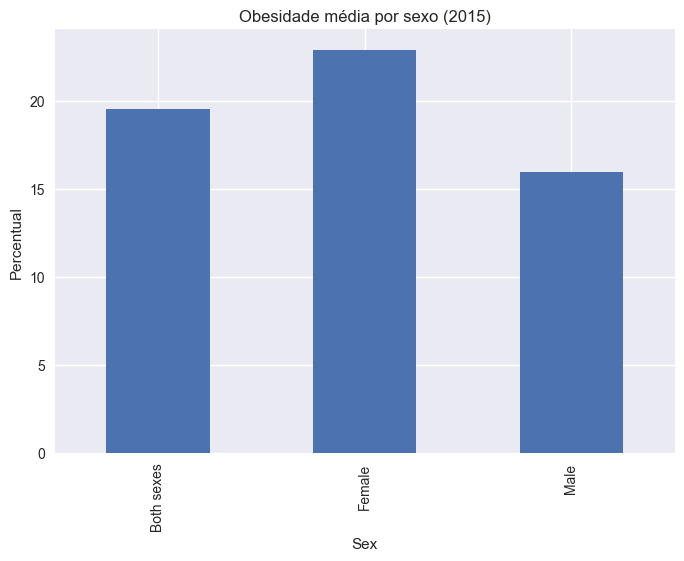

In [16]:
df_2015 = df_obesity[df_obesity.index == 2015]

media_sexo = df_2015.groupby("Sex")["Obesity"].mean()

media_sexo.plot(kind="bar", title="Obesidade média por sexo (2015)")
plt.ylabel("Percentual")
plt.show()

🌎 Top 10 países mais obesos

In [17]:
df_obesity_start = df_obesity[df_obesity.index == 1975]
df_obesity_end = df_obesity[df_obesity.index == 2016]

df_obesity_start.set_index("Country", inplace=True)
df_obesity_end.set_index("Country", inplace=True)

In [18]:
df_obesity_ev = df_obesity_end[df_obesity_end["Sex"] == "Both sexes"]["Obesity"] - df_obesity_start[df_obesity_start["Sex"] == "Both sexes"]["Obesity"]

In [19]:
df_obesity_ev.sort_values().dropna().head(10)

Country
Viet Nam             2.0
Singapore            3.1
Japan                3.3
Bangladesh           3.4
Timor-Leste          3.6
India                3.6
Cambodia             3.6
Nepal                3.8
Ethiopia             4.0
Republic of Korea    4.1
Name: Obesity, dtype: float64

In [20]:
df_obesity_ev.sort_values().dropna().tail(10)

Country
Saudi Arabia                        24.6
Marshall Islands                    25.9
Micronesia (Federated States of)    26.9
Palau                               27.0
Samoa                               27.1
Cook Islands                        27.9
Tonga                               28.3
Kiribati                            30.1
Niue                                31.1
Tuvalu                              33.7
Name: Obesity, dtype: float64

Os países com maiores e menores níveis percetuais de obesidade em 2015.

In [21]:
df_2015 = df_obesity[df_obesity.index == 2015].copy()
df_2015[df_2015["Obesity"] == df_2015["Obesity"].max()]

,Country,Obesity (%),Sex,Obesity
Year,,,,
2015.0,Nauru,63.1 [55.5-70.3],Female,63.1


In [22]:
df_2015 = df_obesity[df_obesity.index == 2015].copy()
df_2015[df_2015["Obesity"] == df_2015["Obesity"].min()]

,Country,Obesity (%),Sex,Obesity
Year,,,,
2015.0,Viet Nam,1.5 [0.8-2.5],Male,1.5


📉 Evolução da obesidade no Brasil

In [23]:
df_brasil = df_obesity[df_obesity["Country"] == "Brazil"]

<Axes: xlabel='Year'>

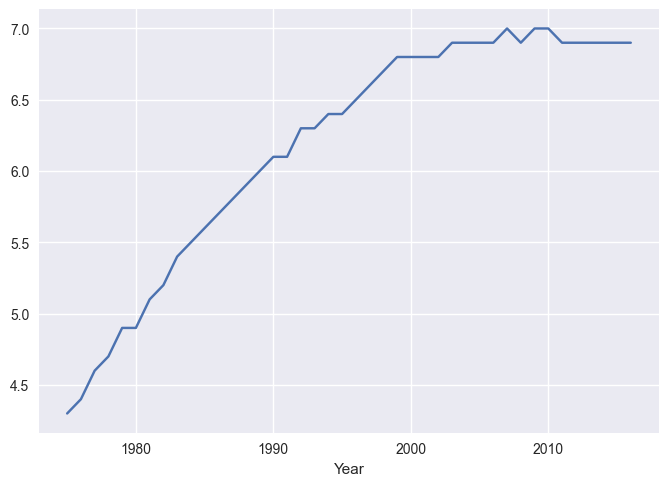

In [24]:
(df_brasil[df_brasil["Sex"] == "Female"]["Obesity"] - df_brasil[df_brasil["Sex"] == "Male"]["Obesity"]).plot()

Gráfico mostrando a evolução da obesidade para ambos sexos no Brasil.

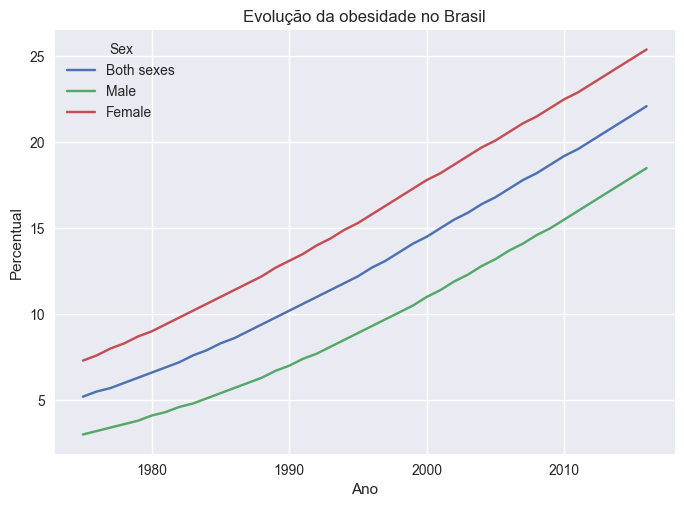

In [25]:
df_brasil = df_obesity[df_obesity["Country"] == "Brazil"]

sns.lineplot(data=df_brasil, x=df_brasil.index, y="Obesity", hue="Sex")

plt.title("Evolução da obesidade no Brasil")
plt.xlabel("Ano")
plt.ylabel("Percentual")
plt.show()

### 📊 Principais insights

A análise dos dados revela alguns padrões importantes:

• A obesidade média global é maior entre mulheres do que homens.

• Diversos países apresentaram crescimento significativo entre 1975 e 2016.

• Países desenvolvidos tendem a apresentar maiores taxas de obesidade.

• No Brasil, observa-se crescimento contínuo da obesidade ao longo do tempo.

## 📊 1️⃣ Criar a seção do PIB

### 📊 Análise do PIB per capita (GDP per person)

Além da análise da obesidade, também será analisado o PIB per capita 
dos países ao longo do tempo.

O objetivo é entender como a evolução econômica pode estar relacionada 
a mudanças nos padrões de obesidade global.

#### 📂 2️⃣ Carregar os dados do PIB

In [26]:
df_gdp = pd.read_csv("../data/gdp.csv", decimal=".")
df_gdp.head()

,Country,Region,Year,GDP_pp
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1901,613.99
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1906,624.04
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1911,634.25
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1916,647.28
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1/1/1921,662.40


In [27]:
df_gdp.columns

Index(['Country', 'Region', 'Year', ' GDP_pp '], dtype='object')

#### 🧹 3️⃣ Limpeza dos dados do PIB

In [28]:
df_gdp["Year"] = df_gdp["Year"].apply(lambda x: int(x.split("/")[-1]))

In [29]:
df_gdp["gdp_pp"] = df_gdp[" GDP_pp "].apply(lambda x: float(x.split(" ")[1].replace(",", "")))
del df_gdp[" GDP_pp "]

In [30]:
df_gdp.head(3)

,Country,Region,Year,gdp_pp
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901,613.99
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1906,624.04
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1911,634.25


 Primeiro valor registrado de cada país

In [31]:
df_gdp.groupby("Country").min()["Year"]

Country
Afghanistan    1901
Albania        1901
Algeria        1901
Andorra        1901
Angola         1901
               ... 
Venezuela      1901
Vietnam        1901
Yemen, Rep.    1901
Zambia         1901
Zimbabwe       1901
Name: Year, Length: 193, dtype: int64

In [32]:
df_gdp.groupby("Country").min()["Year"].isna().sum()

0

In [33]:
df_gdp.groupby("Country").min()["Year"].value_counts()

Year
1901    192
1991      1
Name: count, dtype: int64

In [34]:
df_gdp.groupby("Country").min()["Year"][df_gdp.groupby("Country").min()["Year"] == 1991]

Country
Kosovo    1991
Name: Year, dtype: int64

Regiões com maiores crescimentos de PIB per capita no século passado.

In [35]:
df_gdp[df_gdp["Year"] < 2000]["Year"].max()

1996

In [36]:
df_gdp_start = df_gdp[(df_gdp["Year"] == 1901)]
df_gdp_end = df_gdp[(df_gdp["Year"] == 1996)]

In [37]:
((df_gdp_end.groupby("Region")["gdp_pp"].mean() / df_gdp_start.groupby("Region")["gdp_pp"].mean() - 1) * 100).sort_values(ascending=False)

Region
Middle East, North Africa, and Greater Arabia    857.215950
Asia                                             711.761516
Europe                                           594.046167
North America                                    589.760175
Central America and the Caribbean                406.426789
Australia and Oceania                            396.075383
South America                                    312.123735
Sub-Saharan Africa                               248.633780
Name: gdp_pp, dtype: float64

- Preechendo os anos ausentes em cada país com uma estimativa, baseada na diferença entre o próximo registro e o anterior.

In [38]:
df_gdp.head()

,Country,Region,Year,gdp_pp
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901,613.99
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1906,624.04
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1911,634.25
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1916,647.28
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1921,662.40


In [39]:
arr_years = np.arange(df_gdp["Year"].min(), df_gdp["Year"].max())
df_all_years = pd.DataFrame(arr_years, columns=["Year"])
df_all_years.index = df_all_years["Year"]

df_years_off = ~df_all_years["Year"].isin(df_gdp["Year"])
df_years_off = df_years_off[df_years_off].index

In [40]:
df_years_off

Index([1902, 1903, 1904, 1905, 1907, 1908, 1909, 1910, 1912, 1913, 1914, 1915,
       1917, 1918, 1919, 1920, 1922, 1923, 1924, 1925, 1927, 1928, 1929, 1930,
       1932, 1933, 1934, 1935, 1937, 1938, 1939, 1940, 1942, 1943, 1944, 1945,
       1947, 1948, 1949, 1950, 1952, 1953, 1954, 1955, 1957, 1958, 1959, 1960,
       1962, 1963, 1964, 1965, 1967, 1968, 1969, 1970, 1972, 1973, 1974, 1975,
       1977, 1978, 1979, 1980, 1982, 1983, 1984, 1985, 1987, 1988, 1989, 1990,
       1992, 1993, 1994, 1995, 1997, 1998, 1999, 2000, 2002, 2003, 2004, 2005,
       2007, 2008, 2009, 2010],
      dtype='int32', name='Year')

In [41]:
df_gdp

,Country,Region,Year,gdp_pp
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901,613.99
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1906,624.04
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1911,634.25
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1916,647.28
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1921,662.40
...,...,...,...,...
4414,Zimbabwe,Sub-Saharan Africa,1991,782.09
4415,Zimbabwe,Sub-Saharan Africa,1996,781.50
4416,Zimbabwe,Sub-Saharan Africa,2001,719.96
4417,Zimbabwe,Sub-Saharan Africa,2006,520.17


In [42]:
df_gdp = df_gdp.sort_values(["Country", "Year"])

df_gdp["delta_gdp"] = df_gdp["gdp_pp"] - df_gdp["gdp_pp"].shift(1)
df_gdp["delta_year"] = df_gdp["Year"] - df_gdp["Year"].shift(1)
df_gdp["gdp_year"] = (df_gdp["delta_gdp"] / df_gdp["delta_year"]).shift(-1)

In [43]:
df_gdp["next_year"] = df_gdp["Year"].shift(-1)
del df_gdp["delta_gdp"], df_gdp["delta_year"]

In [44]:
df_new_data = pd.DataFrame()

for idx, row in df_gdp.iterrows():
    if row["Year"] == 2011:
        continue
    
    # print(idx, row)
    year_to_add = df_years_off[(df_years_off < row["next_year"]) & (df_years_off >row["Year"])]
    
    for new_year in year_to_add:
        add_row = row.copy()
        add_row["gdp_pp"] = (new_year - add_row["Year"]) * add_row["gdp_year"] + add_row["gdp_pp"]
        add_row["Year"] = new_year
        df_new_data["kind"] = "estimated"
        df_new_data = pd.concat([df_new_data, add_row.to_frame().transpose()])

In [45]:
df_gdp.iloc[100:].head(10)

,Country,Region,Year,gdp_pp,gdp_year,next_year
100,Angola,Sub-Saharan Africa,1941,2170.80,119.530,1946.0
101,Angola,Sub-Saharan Africa,1946,2768.45,134.490,1951.0
102,Angola,Sub-Saharan Africa,1951,3440.90,21.628,1956.0
103,Angola,Sub-Saharan Africa,1956,3549.04,182.958,1961.0
104,Angola,Sub-Saharan Africa,1961,4463.83,168.862,1966.0
105,Angola,Sub-Saharan Africa,1966,5308.14,43.614,1971.0
106,Angola,Sub-Saharan Africa,1971,5526.21,-495.178,1976.0
107,Angola,Sub-Saharan Africa,1976,3050.32,-19.382,1981.0
108,Angola,Sub-Saharan Africa,1981,2953.41,-146.560,1986.0
109,Angola,Sub-Saharan Africa,1986,2220.61,102.048,1991.0


In [46]:
df_gdp = pd.concat([df_gdp, df_new_data]).sort_values(["Country", "Year"])
df_gdp["kind"].fillna("real", inplace=True)
df_gdp.index = df_gdp["Year"]

C:\Users\ra918\AppData\Local\Temp\ipykernel_21404\2618567338.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_gdp["kind"].fillna("real", inplace=True)


<Axes: xlabel='Year', ylabel='gdp_pp'>

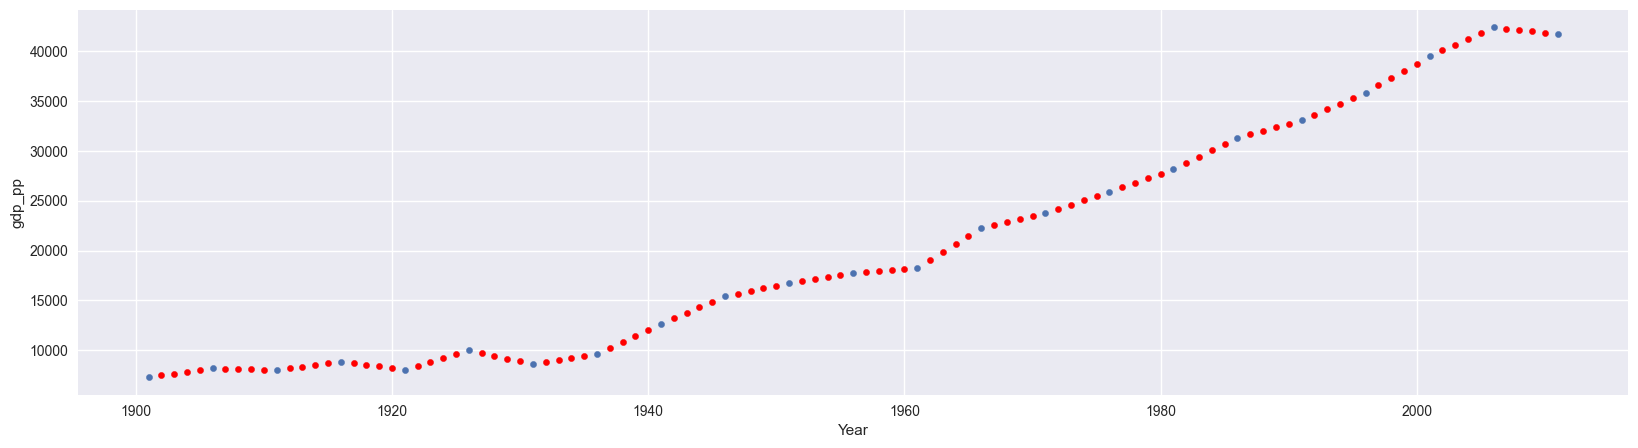

In [47]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20, 5))
df_gdp[(df_gdp["kind"] == "real") & (df_gdp["Country"] == "United States")].plot(kind="scatter", y="gdp_pp", x="Year", ax=ax)
df_gdp[(df_gdp["kind"] == "estimated") & (df_gdp["Country"] == "United States")].plot(kind="scatter", y="gdp_pp", x="Year", ax=ax, color="red")

Criando um mapa do gdp no mundo ao longo dos anos.

In [48]:
df_gdp[df_gdp["kind"] == "real"].reset_index(drop=True).head(5)

,Country,Region,Year,gdp_pp,gdp_year,next_year,kind
0,Afghanistan,"Middle East, North Africa, and Greater Arabia",1901,613.99,2.01,1906.0,real
1,Afghanistan,"Middle East, North Africa, and Greater Arabia",1906,624.04,2.042,1911.0,real
2,Afghanistan,"Middle East, North Africa, and Greater Arabia",1911,634.25,2.606,1916.0,real
3,Afghanistan,"Middle East, North Africa, and Greater Arabia",1916,647.28,3.024,1921.0,real
4,Afghanistan,"Middle East, North Africa, and Greater Arabia",1921,662.4,3.094,1926.0,real


In [49]:
df_gdp["Year"] = df_gdp["Year"].astype(int)
df_gdp["gdp_pp"] = df_gdp["gdp_pp"].astype(float)

In [50]:
import plotly.express as px

df = px.data.gapminder()
dict_iso_alpha = df.set_index("country").to_dict()["iso_alpha"]
dict_num = {j: i for i, j in enumerate(df_gdp["Country"].unique())}

df_gdp["iso_alpha"] = df_gdp["Country"].map(dict_iso_alpha)
df_gdp["iso_num"] = df_gdp["Country"].map(dict_num)

fig = px.choropleth(df_gdp[df_gdp["kind"] == "real"].reset_index(drop=True), locations="iso_alpha", color="gdp_pp", hover_name="Country", animation_frame="Year")

fig.update_layout(height=600)
fig.show()

Descobrindo se existe uma relação entre níveis de obesidade e gdp per capita.

In [51]:
df_obesity["country-year"] = df_obesity["Country"] + "-" + df_obesity.reset_index()["Year"].apply(lambda x: str(int(x))).values
dict_obesity_year = df_obesity.set_index("country-year").to_dict()["Obesity"]

In [52]:
df_gdp["country-year"] = df_gdp["Country"] + "-" + df_gdp["Year"].apply(lambda x: str(x)).values
df_gdp["Obesity"] = df_gdp["country-year"].map(dict_obesity_year)

In [53]:
df_gdp_clean = df_gdp.dropna()

In [54]:
countries = df_gdp_clean["Country"].unique()

In [55]:
corr_list = []
for country in countries:
    corr_list += [df_gdp_clean[df_gdp_clean["Country"] == country][["Obesity", "gdp_pp"]].corr().iloc[0, 1]]

df_corr = pd.Series(corr_list, index=countries)

In [56]:
df_corr.mean()

0.5156020945367675

In [57]:
df_corr.std()

0.6523066623226486

<Axes: >

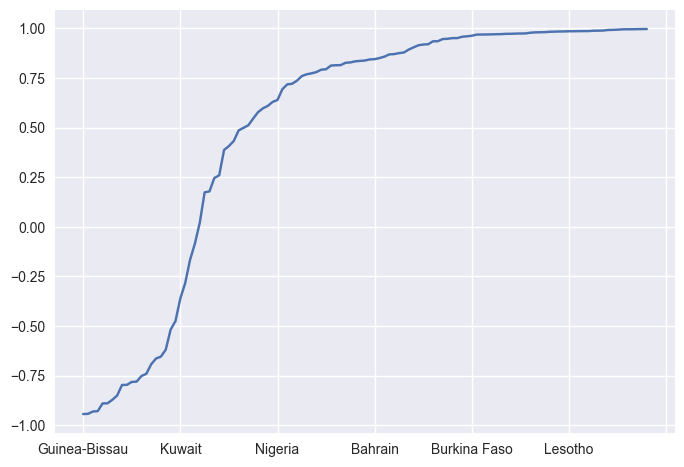

In [58]:
df_corr.sort_values().plot()

<Axes: xlabel='Year'>

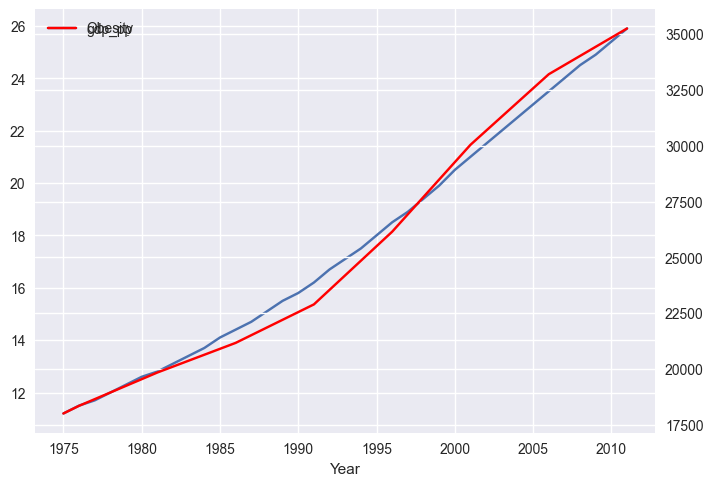

In [59]:
country = "Australia"
fig, ax = plt.subplots()
df_gdp_clean[df_gdp_clean["Country"] == country][["Obesity"]].plot(ax=ax)
ax2 = ax.twinx()
df_gdp_clean[df_gdp_clean["Country"] == country][["gdp_pp"]].plot(ax=ax2, color="red")

In [60]:
df_gdp_clean

,Country,Region,Year,gdp_pp,gdp_year,next_year,kind,iso_alpha,iso_num,country-year,Obesity
Year,,,,,,,,,,,
1975,Afghanistan,"Middle East, North Africa, and Greater Arabia",1975,847.692,18.498,1976.0,estimated,AFG,0,Afghanistan-1975,0.8
1976,Afghanistan,"Middle East, North Africa, and Greater Arabia",1976,866.190,6.134,1981.0,real,AFG,0,Afghanistan-1976,0.8
1977,Afghanistan,"Middle East, North Africa, and Greater Arabia",1977,872.324,6.134,1981.0,estimated,AFG,0,Afghanistan-1977,0.9
1978,Afghanistan,"Middle East, North Africa, and Greater Arabia",1978,878.458,6.134,1981.0,estimated,AFG,0,Afghanistan-1978,0.9
1979,Afghanistan,"Middle East, North Africa, and Greater Arabia",1979,884.592,6.134,1981.0,estimated,AFG,0,Afghanistan-1979,1.0
...,...,...,...,...,...,...,...,...,...,...,...
2006,Zimbabwe,Sub-Saharan Africa,2006,520.170,1.232,2011.0,real,ZWE,192,Zimbabwe-2006,20.9
2007,Zimbabwe,Sub-Saharan Africa,2007,521.402,1.232,2011.0,estimated,ZWE,192,Zimbabwe-2007,21.3
2008,Zimbabwe,Sub-Saharan Africa,2008,522.634,1.232,2011.0,estimated,ZWE,192,Zimbabwe-2008,21.7


In [61]:
df_gdp_clean.reset_index(drop=True).groupby("Year")[["Obesity", "gdp_pp"]].mean().corr().iloc[0, 1]

0.9693775432125091